# CSE457 — Lab 1: Phân tích và xử lý tín hiệu âm thanh số

Dữ liệu: **datalab1.mp3**. Thực hiện A–G theo Lab 1, trang 4–5 và 9–10.
Chạy **Run All** từ thư mục chứa notebook và MP3. Kết quả ở `Lab01_output/`;
cell cuối tạo `report_Lab01.md` với số liệu, hình và đáp án 7 câu hỏi.

Cài môi trường một lần trong terminal: `python -m pip install -r requirements.txt`.
Chọn kernel Python tương ứng.
Tệp đầu vào MP3 đã nén mất dữ liệu; PCM16 chỉ là định dạng tham chiếu.
Nhận xét thính giác bên dưới là dự đoán từ phép đo, chưa phải khảo sát người nghe.


In [1]:
from pathlib import Path
import hashlib
import json
import math
import platform
import sys

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import scipy
from scipy import signal
import soundfile as sf
from IPython.display import Audio, Markdown, display
from IPython import get_ipython

if get_ipython() is not None:
    get_ipython().run_line_magic('matplotlib', 'inline')

BASE_DIR = Path.cwd()
INPUT_FILE = BASE_DIR / 'datalab1.mp3'
if not INPUT_FILE.is_file():
    raise FileNotFoundError('Đặt datalab1.mp3 cùng thư mục notebook và chạy từ thư mục đó.')
OUTPUT_DIR = BASE_DIR / 'Lab01_output'
AUDIO_DIR, FIG_DIR = OUTPUT_DIR / 'audio', OUTPUT_DIR / 'figures'
for directory in (AUDIO_DIR, FIG_DIR):
    directory.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({'figure.figsize': (12, 4), 'axes.grid': True, 'grid.alpha': .2})
sections, generated_figures, generated_audio = [], [], []

def rms(values):
    return float(np.sqrt(np.mean(np.asarray(values, dtype=float) ** 2)))

def dbfs(value):
    return float(20 * np.log10(value)) if value > 0 else float('-inf')

def snr(reference, processed):
    power = np.sum(np.asarray(reference, dtype=float) ** 2)
    error = np.sum((np.asarray(processed, dtype=float) - reference) ** 2)
    if error == 0:
        return float('inf') if power > 0 else float('nan')
    return float(10 * np.log10(power / error)) if power > 0 else float('-inf')

def amplitude_spectrum(values, fs, nfft=None, window='hamming'):
    """One-sided peak amplitude; coherent-gain correction, no per-curve peak scaling."""
    values = np.asarray(values, dtype=float)
    if values.ndim != 1 or len(values) < 2:
        raise ValueError('Cần một đoạn mono có ít nhất 2 mẫu.')
    nfft = nfft or (1 << (len(values) - 1).bit_length())
    if nfft < len(values):
        raise ValueError('NFFT phải >= số mẫu; không cho phép FFT tự cắt dữ liệu.')
    weights = np.hamming(len(values)) if window == 'hamming' else np.ones(len(values))
    amplitude = np.abs(np.fft.rfft(values * weights, n=nfft)) / weights.sum()
    amplitude[1:] *= 2
    if nfft % 2 == 0:
        amplitude[-1] /= 2
    return np.fft.rfftfreq(nfft, 1 / fs), amplitude

def amplitude_db(amplitude):
    # Reference = sinusoid peak amplitude 1; floor -240 dB for plotting only.
    return 20 * np.log10(np.maximum(amplitude, 1e-12))

def save_figure(name, figure=None):
    figure = figure or plt.gcf()
    figure.tight_layout()
    figure.savefig(FIG_DIR / name, dpi=140, bbox_inches='tight')
    generated_figures.append(name)
    display(figure)
    plt.close(figure)

def write_audio(name, values, fs, subtype='PCM_16'):
    values = np.asarray(values)
    if not np.all(np.isfinite(values)) or np.max(np.abs(values)) > 1:
        raise ValueError(f'{name}: có NaN/Inf hoặc vượt full scale; cần xử lý trước khi ghi.')
    path = AUDIO_DIR / name
    sf.write(str(path), values, fs, subtype=subtype)
    generated_audio.append(name)
    return path

def table_md(table):
    def fmt(value):
        if isinstance(value, (float, np.floating)):
            return f'{value:.6g}'
        return str(value).replace('|', '/').replace('\n', ' ')
    rows = ['| ' + ' | '.join(map(str, table.columns)) + ' |',
            '| ' + ' | '.join(['---'] * len(table.columns)) + ' |']
    rows.extend('| ' + ' | '.join(fmt(v) for v in row) + ' |'
                for row in table.itertuples(index=False, name=None))
    return '\n'.join(rows)

def section(title, text, tables=(), figures=(), audio_files=()):
    parts = ['## ' + title, text]
    parts.extend(table_md(table) for table in tables)
    parts.extend(f'![{caption}](Lab01_output/figures/{name})\n\n*{caption}*'
                 for name, caption in figures)
    if audio_files:
        parts.append('Audio: ' + ' · '.join(f'[{name}](Lab01_output/audio/{name})' for name in audio_files))
    sections.append('\n\n'.join(parts))
    display(Markdown(text))

def play_comparison(items, start, seconds=4):
    for label, values, fs in items:
        a, b = int(start * fs), int((start + seconds) * fs)
        clip = np.asarray(values)[a:b]
        display(Markdown(f'**{label} — {start:.2f}–{start + len(clip)/fs:.2f} s; không tự tăng âm lượng**'))
        display(Audio(clip, rate=fs, normalize=False))

print('Input:', INPUT_FILE.resolve())
print('Python:', platform.python_version(), '| NumPy:', np.__version__, '| SciPy:', scipy.__version__)


Input: C:\xulyamthanh\lab 1\datalab1.mp3
Python: 3.10.5 | NumPy: 2.2.6 | SciPy: 1.15.3


## A. Đọc dữ liệu, chuyển stereo thành mono
Dùng chung hệ số chuẩn hóa cho tất cả kênh, không giới hạn biên độ bằng clip.
Waveform và RMS được so sánh trên cùng thang đo. MP3 không có bit depth PCM cố định.


,Thuộc tính,Giá trị,Đơn vị
0,File,datalab1.mp3,
1,Format,MP3,
2,Subtype,MPEG_LAYER_III,
3,Sampling rate,44100,Hz
4,Channels,2,
5,Duration,214.343401,s
6,Decoded dtype,float64,
7,MP3 size,3697728,byte
8,PCM reference,16,bit/sample
9,Common normalization gain,1.0,


,Tín hiệu,Peak,RMS,RMS_dBFS
0,Kênh 1,0.937987,0.160368,-15.897642
1,Kênh 2,0.923114,0.159937,-15.921014
2,Mono,0.853090,0.143072,-16.888906


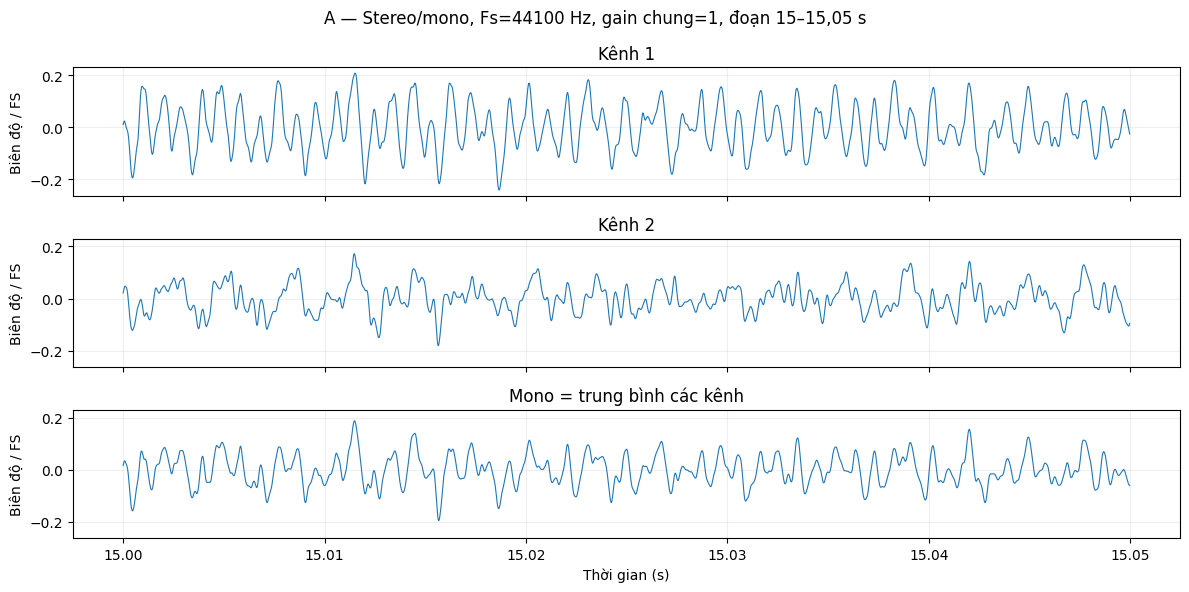

Tệp có 2 kênh, Fs = 44100 Hz và thời lượng 214.343401 s; miền biểu diễn độc lập kết thúc ở 22050 Hz. RMS các kênh là 0.160368, 0.159937, còn mono là 0.143072 (-16.89 dBFS), cho thấy việc lấy trung bình kênh làm thay đổi mức tín hiệu. Gain chuẩn hóa chung bằng 1; không chuẩn hóa riêng từng kênh nên vẫn giữ tương quan mức giữa chúng. MP3 không có bit depth PCM cố định; float64 là kiểu tính toán, còn PCM16 là cấu hình xuất tham chiếu.

In [2]:
info = sf.info(str(INPUT_FILE))
x_multi_raw, Fs = sf.read(str(INPUT_FILE), dtype='float64', always_2d=True)
assert np.all(np.isfinite(x_multi_raw))
channels = x_multi_raw.shape[1]
duration = len(x_multi_raw) / Fs
if duration < 20 or Fs < 16000:
    raise ValueError('Thí nghiệm này cần audio ít nhất 20 s, Fs >= 16 kHz.')
raw_peak = float(np.max(np.abs(x_multi_raw)))
normalization_gain = 1 / max(1., raw_peak)
x_multi = x_multi_raw * normalization_gain
x = x_multi.mean(axis=1)
PCM_BITS = 16
mono_path = write_audio('input_mono_PCM16.wav', x, Fs)
metadata = pd.DataFrame([
    ['File', INPUT_FILE.name, ''], ['Format', info.format, ''], ['Subtype', info.subtype, ''],
    ['Sampling rate', Fs, 'Hz'], ['Channels', channels, ''], ['Duration', duration, 's'],
    ['Decoded dtype', str(x_multi_raw.dtype), ''], ['MP3 size', INPUT_FILE.stat().st_size, 'byte'],
    ['PCM reference', PCM_BITS, 'bit/sample'], ['Common normalization gain', normalization_gain, ''],
], columns=['Thuộc tính', 'Giá trị', 'Đơn vị'])
channel_table = pd.DataFrame([
    {'Tín hiệu': f'Kênh {i+1}', 'Peak': np.max(np.abs(x_multi[:, i])),
     'RMS': rms(x_multi[:, i]), 'RMS_dBFS': dbfs(rms(x_multi[:, i]))}
    for i in range(channels)
] + [{'Tín hiệu': 'Mono', 'Peak': np.max(np.abs(x)), 'RMS': rms(x), 'RMS_dBFS': dbfs(rms(x))}])
metadata.to_csv(OUTPUT_DIR / 'metadata.csv', index=False)
channel_table.to_csv(OUTPUT_DIR / 'channel_comparison.csv', index=False)
display(metadata, channel_table)

a, b = int(15 * Fs), int(15.05 * Fs)
fig, axes = plt.subplots(channels + 1, 1, figsize=(12, 2 * (channels + 1)), sharex=True, sharey=True)
for i, values in enumerate([*x_multi.T, x]):
    axes[i].plot(np.arange(a, b) / Fs, values[a:b], lw=.8)
    axes[i].set_ylabel('Biên độ / FS')
    axes[i].set_title(f'Kênh {i+1}' if i < channels else 'Mono = trung bình các kênh')
axes[-1].set_xlabel('Thời gian (s)')
fig.suptitle(f'A — Stereo/mono, Fs={Fs} Hz, gain chung={normalization_gain:.6g}, đoạn 15–15,05 s')
save_figure('A_stereo_mono.png', fig)
section('A. Metadata và stereo–mono',
    f'Tệp có {channels} kênh, Fs = {Fs} Hz và thời lượng {duration:.6f} s; miền biểu diễn độc lập kết thúc ở {Fs/2:g} Hz. '
    f'RMS các kênh là {", ".join(f"{v:.6f}" for v in channel_table.RMS.iloc[:-1])}, còn mono là {rms(x):.6f} '
    f'({dbfs(rms(x)):.2f} dBFS), cho thấy việc lấy trung bình kênh làm thay đổi mức tín hiệu. '
    f'Gain chuẩn hóa chung bằng {normalization_gain:.6g}; không chuẩn hóa riêng từng kênh nên vẫn giữ tương quan mức giữa chúng. '
    'MP3 không có bit depth PCM cố định; float64 là kiểu tính toán, còn PCM16 là cấu hình xuất tham chiếu.',
    tables=[metadata, channel_table], figures=[('A_stereo_mono.png', 'Các kênh và mono: cùng thời gian, gain và thang biên độ.')])


## B. Miền thời gian và hai đoạn có đặc tính khác nhau
E = ∑x²; RMS = sqrt(mean(x²)). Ngưỡng 0,999 chỉ phát hiện mẫu gần full scale,
không thể xác định mọi trường hợp clipping từng xảy ra trước khi mã hóa MP3.


,Peak_mono,RMS_mono,RMS_dBFS,Energy_sum_x2,Mono_samples_abs_ge_0.999,Input_channel_samples_abs_ge_1
0,0.85309,0.143072,-16.888906,193489.828293,0,0


,start_s,end_s,RMS,Peak,RMS_dBFS
0,0.0,1.0,0.000000,0.000000,-inf
120,120.0,121.0,0.204232,0.640338,-13.797512


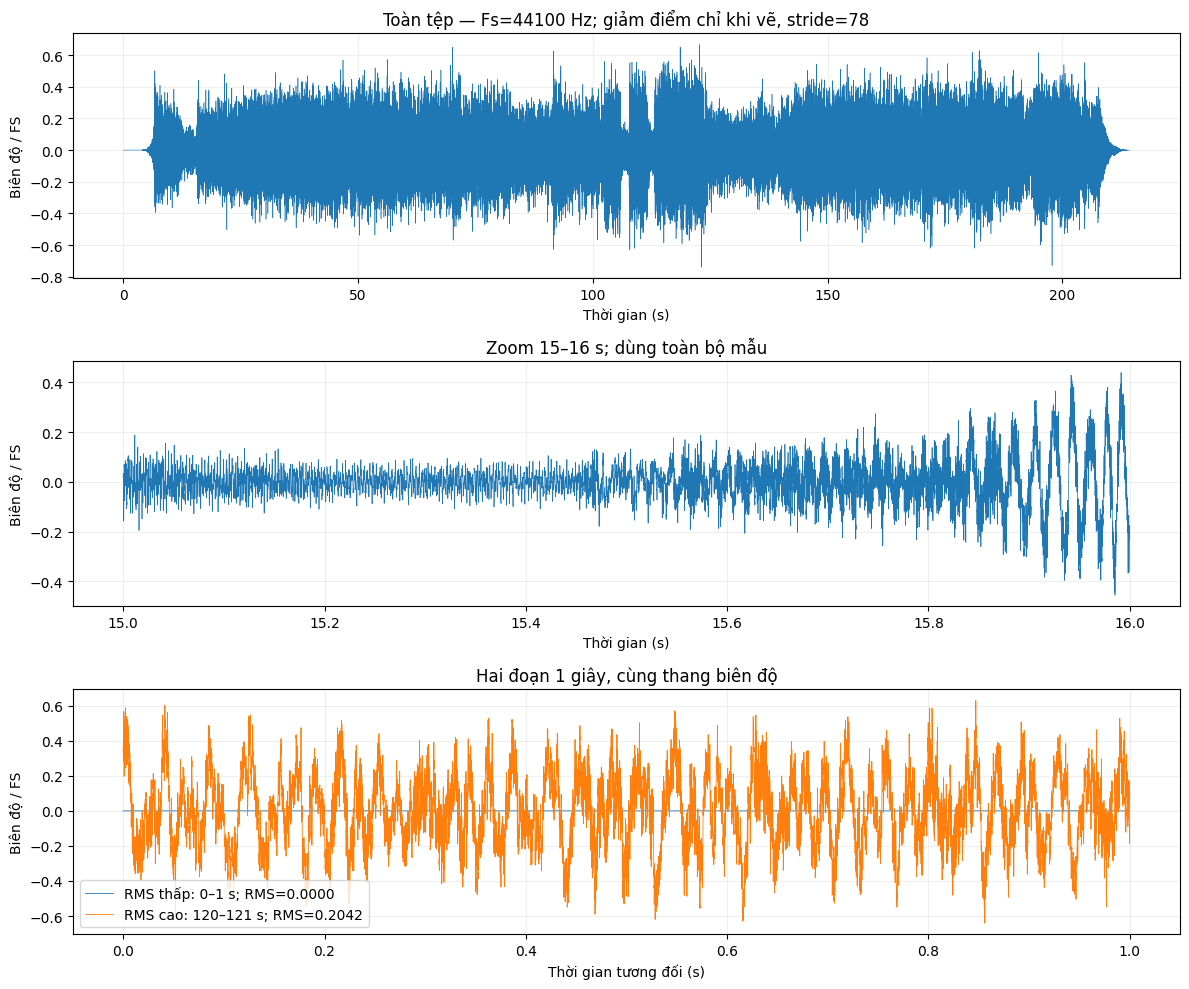

Peak mono = 0.853090, RMS = 0.143072 và năng lượng ∑x² = 193489.828; có 0 mẫu mono đạt ngưỡng |x| ≥ 0,999 nên kiểm tra này không phát hiện nguy cơ clipping tại full scale. Đoạn 0–1 s có RMS = 0.000000, trong khi đoạn 120–121 s có RMS = 0.204232; hình cho thấy khác biệt rõ về mức năng lượng. Với đoạn im lặng RMS = 0, mức RMS là −∞ dBFS, không diễn giải sàn số dùng khi vẽ log là âm thanh thật. Các số liệu được tính từ toàn bộ mẫu; chỉ waveform toàn tệp giảm số điểm khi hiển thị.

In [3]:
peak, rms_full = float(np.max(np.abs(x))), rms(x)
energy = float(np.sum(x*x))
near_fullscale_count = int(np.count_nonzero(np.abs(x) >= .999))
fullscale_input_count = int(np.count_nonzero(np.abs(x_multi_raw) >= 1))
time_table = pd.DataFrame([{'Peak_mono': peak, 'RMS_mono': rms_full,
    'RMS_dBFS': dbfs(rms_full), 'Energy_sum_x2': energy,
    'Mono_samples_abs_ge_0.999': near_fullscale_count, 'Input_channel_samples_abs_ge_1': fullscale_input_count}])
one_second = int(Fs)
segment_table = pd.DataFrame([
    {'start_s': a/Fs, 'end_s': (a+one_second)/Fs, 'RMS': rms(x[a:a+one_second]),
     'Peak': float(np.max(np.abs(x[a:a+one_second])))}
    for a in range(0, len(x)-one_second+1, one_second)
])
segment_table['RMS_dBFS'] = segment_table.RMS.map(dbfs)
low_row, high_row = segment_table.loc[segment_table.RMS.idxmin()], segment_table.loc[segment_table.RMS.idxmax()]
selected_segments = pd.DataFrame([low_row, high_row])
for name, row in [('low', low_row), ('high', high_row)]:
    a = int(row.start_s * Fs)
    write_audio(f'segment_{name}_rms.wav', x[a:a+one_second], Fs)
time_table.to_csv(OUTPUT_DIR / 'time_metrics.csv', index=False)
segment_table.to_csv(OUTPUT_DIR / 'segments_1s.csv', index=False)
display(time_table, selected_segments)
fig, axes = plt.subplots(3, 1, figsize=(12, 10))
stride = max(1, len(x)//120000)
axes[0].plot(np.arange(0, len(x), stride)/Fs, x[::stride], lw=.4)
axes[0].set_title(f'Toàn tệp — Fs={Fs} Hz; giảm điểm chỉ khi vẽ, stride={stride}')
axes[0].set_xlabel('Thời gian (s)')
a, b = int(15*Fs), int(16*Fs)
axes[1].plot(np.arange(a,b)/Fs, x[a:b], lw=.5)
axes[1].set_title('Zoom 15–16 s; dùng toàn bộ mẫu')
axes[1].set_xlabel('Thời gian (s)')
for row, label in [(low_row, 'RMS thấp'), (high_row, 'RMS cao')]:
    a = int(row.start_s*Fs)
    axes[2].plot(np.arange(one_second)/Fs, x[a:a+one_second], lw=.6,
                 label=f'{label}: {row.start_s:g}–{row.end_s:g} s; RMS={row.RMS:.4f}')
axes[2].legend()
axes[2].set_title('Hai đoạn 1 giây, cùng thang biên độ')
axes[2].set_xlabel('Thời gian tương đối (s)')
for ax in axes:
    ax.set_ylabel('Biên độ / FS')
save_figure('B_waveforms.png', fig)
section('B. Phân tích miền thời gian',
    f'Peak mono = {peak:.6f}, RMS = {rms_full:.6f} và năng lượng ∑x² = {energy:.3f}; '
    f'có {near_fullscale_count} mẫu mono đạt ngưỡng |x| ≥ 0,999 nên kiểm tra này không phát hiện nguy cơ clipping tại full scale. '
    f'Đoạn {low_row.start_s:g}–{low_row.end_s:g} s có RMS = {low_row.RMS:.6f}, '
    f'trong khi đoạn {high_row.start_s:g}–{high_row.end_s:g} s có RMS = {high_row.RMS:.6f}; hình cho thấy khác biệt rõ về mức năng lượng. '
    'Với đoạn im lặng RMS = 0, mức RMS là −∞ dBFS, không diễn giải sàn số dùng khi vẽ log là âm thanh thật. '
    'Các số liệu được tính từ toàn bộ mẫu; chỉ waveform toàn tệp giảm số điểm khi hiển thị.',
    tables=[time_table, selected_segments], figures=[('B_waveforms.png', 'Waveform toàn tệp, zoom 1 giây và hai đoạn tương phản.')],
    audio_files=['segment_low_rms.wav', 'segment_high_rms.wav'])


## C. FFT: chọn đoạn tương đối ổn định, so sánh NFFT
Chọn cửa sổ 0,75 s có RMS đủ lớn, rồi tối thiểu hóa CV của RMS và biến đổi phổ
giữa các frame 25 ms. Đây là tiêu chí ổn định tương đối, không chứng minh dừng tuyệt đối.
Cả hai NFFT đều >= độ dài đoạn. Phổ tuyến tính và dB dùng cùng chuẩn biên độ.


,start_s,duration_s,samples_used,NFFT,bin_spacing_Hz
0,140.25,0.75,33075,65536,0.672913
1,140.25,0.75,33075,131072,0.336456


,start_s,RMS_CV,mean_spectral_change,score
174,140.25,0.091216,0.351853,0.443069
175,141.00,0.109588,0.356432,0.466020
176,141.75,0.113166,0.371864,0.485030


,frequency_Hz,peak_amplitude_FS,dB_re_peak_FS1
0,58.206940,0.133984,-17.458911
1,116.077423,0.028278,-30.971088
2,328.717804,0.032882,-29.660930
3,440.084839,0.027182,-31.314323
4,586.106873,0.032040,-29.886058


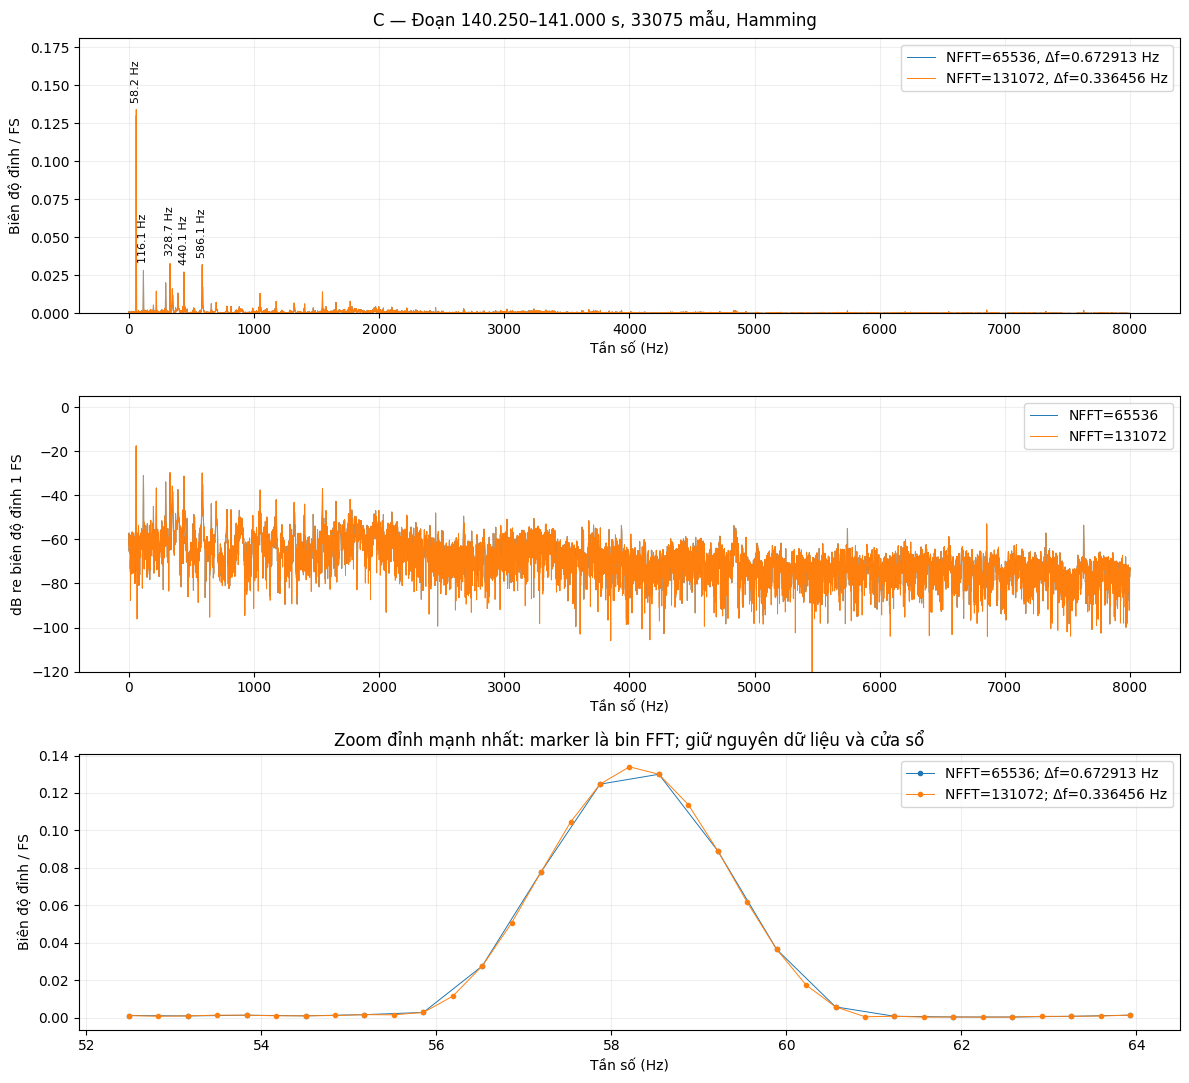

Đoạn 140.250–141.000 s được chọn bằng điểm ổn định nhỏ nhất trong các đoạn hoạt động: CV của RMS = 0.0912, biến đổi phổ trung bình = 0.3519; đây là thước đo ổn định tương đối. Hai NFFT [65536, 131072] dùng nguyên 33075 mẫu và cùng cửa sổ Hamming, không cắt mẫu; Δf giảm từ 0.672913 xuống 0.336456 Hz. Các đỉnh nổi bật ở 58.21, 116.08, 328.72, 440.08, 586.11 Hz, nhưng không đủ cơ sở quy tất cả cho một nguồn âm. Zero-padding chỉ làm lưới phổ dày hơn; khả năng tách hai tần số vẫn phụ thuộc độ dài 0.750 s và main-lobe của Hamming.

In [4]:
FFT_DURATION = .75
segment_len, frame_len = round(FFT_DURATION*Fs), round(.025*Fs)
candidates = []
for start in range(0, len(x)-segment_len+1, segment_len):
    candidate = x[start:start+segment_len]
    if rms(candidate) < .5*rms_full:
        continue
    frames = candidate[:(len(candidate)//frame_len)*frame_len].reshape(-1, frame_len)
    frame_rms = np.sqrt(np.mean(frames*frames, axis=1))
    spectra = np.abs(np.fft.rfft(frames*np.hamming(frame_len), axis=1))
    spectra /= np.maximum(np.linalg.norm(spectra, axis=1, keepdims=True), 1e-12)
    flux = np.linalg.norm(np.diff(spectra, axis=0), axis=1).mean()
    cv = float(frame_rms.std()/frame_rms.mean())
    candidates.append({'start_s': start/Fs, 'RMS_CV': cv, 'mean_spectral_change': flux, 'score': cv+flux})
candidate_table = pd.DataFrame(candidates).sort_values('score')
if candidate_table.empty:
    raise ValueError('Không tìm được đoạn hoạt động phù hợp để FFT.')
chosen = candidate_table.iloc[0]
FFT_START = float(chosen.start_s)
a = round(FFT_START*Fs)
fft_seg = x[a:a+segment_len]
N0 = 1 << (len(fft_seg)-1).bit_length()
NFFT_LIST = [N0, 2*N0]
fft_results = {n: amplitude_spectrum(fft_seg, Fs, n) for n in NFFT_LIST}
fft_parameters = pd.DataFrame([{'start_s': FFT_START, 'duration_s': len(fft_seg)/Fs,
    'samples_used': len(fft_seg), 'NFFT': n, 'bin_spacing_Hz': Fs/n} for n in NFFT_LIST])
f, mag = fft_results[max(NFFT_LIST)]
peaks, _ = signal.find_peaks(amplitude_db(mag), prominence=3, distance=max(1, round(40/(Fs/max(NFFT_LIST)))))
peaks = peaks[(f[peaks]>=50) & (f[peaks]<=min(8000,Fs/2))]
top = peaks[np.argsort(mag[peaks])[-5:]]
top = top[np.argsort(f[top])]
assert len(top) >= 3, 'Cần ít nhất 3 đỉnh nổi bật.'
peak_table = pd.DataFrame({'frequency_Hz': f[top], 'peak_amplitude_FS': mag[top], 'dB_re_peak_FS1': amplitude_db(mag[top])})
candidate_table.to_csv(OUTPUT_DIR/'fft_candidate_stability.csv', index=False)
peak_table.to_csv(OUTPUT_DIR/'fft_peaks.csv', index=False)
fft_parameters.to_csv(OUTPUT_DIR/'fft_parameters.csv', index=False)
display(fft_parameters, candidate_table.head(3), peak_table)
fig, axes = plt.subplots(3,1,figsize=(12,11))
for n, (ff, mm) in fft_results.items():
    mask = ff<=8000
    axes[0].plot(ff[mask],mm[mask],lw=.7,label=f'NFFT={n}, Δf={Fs/n:.6f} Hz')
    axes[1].plot(ff[mask],amplitude_db(mm[mask]),lw=.7,label=f'NFFT={n}')
    strongest_frequency = f[top[np.argmax(mag[top])]]
    near_peak = np.abs(ff-strongest_frequency)<=6
    axes[2].plot(ff[near_peak],mm[near_peak],'o-',ms=3,lw=.7,label=f'NFFT={n}; Δf={Fs/n:.6f} Hz')
for p in top:
    axes[0].annotate(f'{f[p]:.1f} Hz',(f[p],mag[p]),xytext=(0,5),textcoords='offset points',
        fontsize=8,rotation=90,ha='center',va='bottom')
axes[0].set_ylim(0,mag[top].max()*1.35)
axes[0].set_ylabel('Biên độ đỉnh / FS')
axes[0].set_xlabel('Tần số (Hz)')
axes[1].set_ylabel('dB re biên độ đỉnh 1 FS')
axes[1].set_xlabel('Tần số (Hz)')
axes[1].set_ylim(-120,5)
axes[2].set(xlabel='Tần số (Hz)',ylabel='Biên độ đỉnh / FS',title='Zoom đỉnh mạnh nhất: marker là bin FFT; giữ nguyên dữ liệu và cửa sổ')
for ax in axes:
    ax.legend()
fig.suptitle(f'C — Đoạn {FFT_START:.3f}–{FFT_START+len(fft_seg)/Fs:.3f} s, {len(fft_seg)} mẫu, Hamming')
save_figure('C_fft_linear_db.png',fig)
section('C. Phân tích FFT',
    f'Đoạn {FFT_START:.3f}–{FFT_START+len(fft_seg)/Fs:.3f} s được chọn bằng điểm ổn định nhỏ nhất trong các đoạn hoạt động: '
    f'CV của RMS = {chosen.RMS_CV:.4f}, biến đổi phổ trung bình = {chosen.mean_spectral_change:.4f}; đây là thước đo ổn định tương đối. '
    f'Hai NFFT {NFFT_LIST} dùng nguyên {len(fft_seg)} mẫu và cùng cửa sổ Hamming, không cắt mẫu; Δf giảm từ {Fs/N0:.6f} xuống {Fs/(2*N0):.6f} Hz. '
    f'Các đỉnh nổi bật ở {", ".join(f"{v:.2f}" for v in peak_table.frequency_Hz)} Hz, nhưng không đủ cơ sở quy tất cả cho một nguồn âm. '
    f'Zero-padding chỉ làm lưới phổ dày hơn; khả năng tách hai tần số vẫn phụ thuộc độ dài {len(fft_seg)/Fs:.3f} s và main-lobe của Hamming.',
    tables=[fft_parameters, peak_table],figures=[('C_fft_linear_db.png','FFT tuyến tính và dB; hiệu chỉnh gain cửa sổ, dùng cùng chuẩn 1 FS.')])


## D. STFT/spectrogram: frame 10, 25, 50 ms; hop 10 ms
Cùng đoạn 5–15 s, cửa sổ Hamming, NFFT=4096 và thang màu chung 80 dB.
S là magnitude được SciPy scale theo tổng cửa sổ; colorbar ghi dB re S=1.


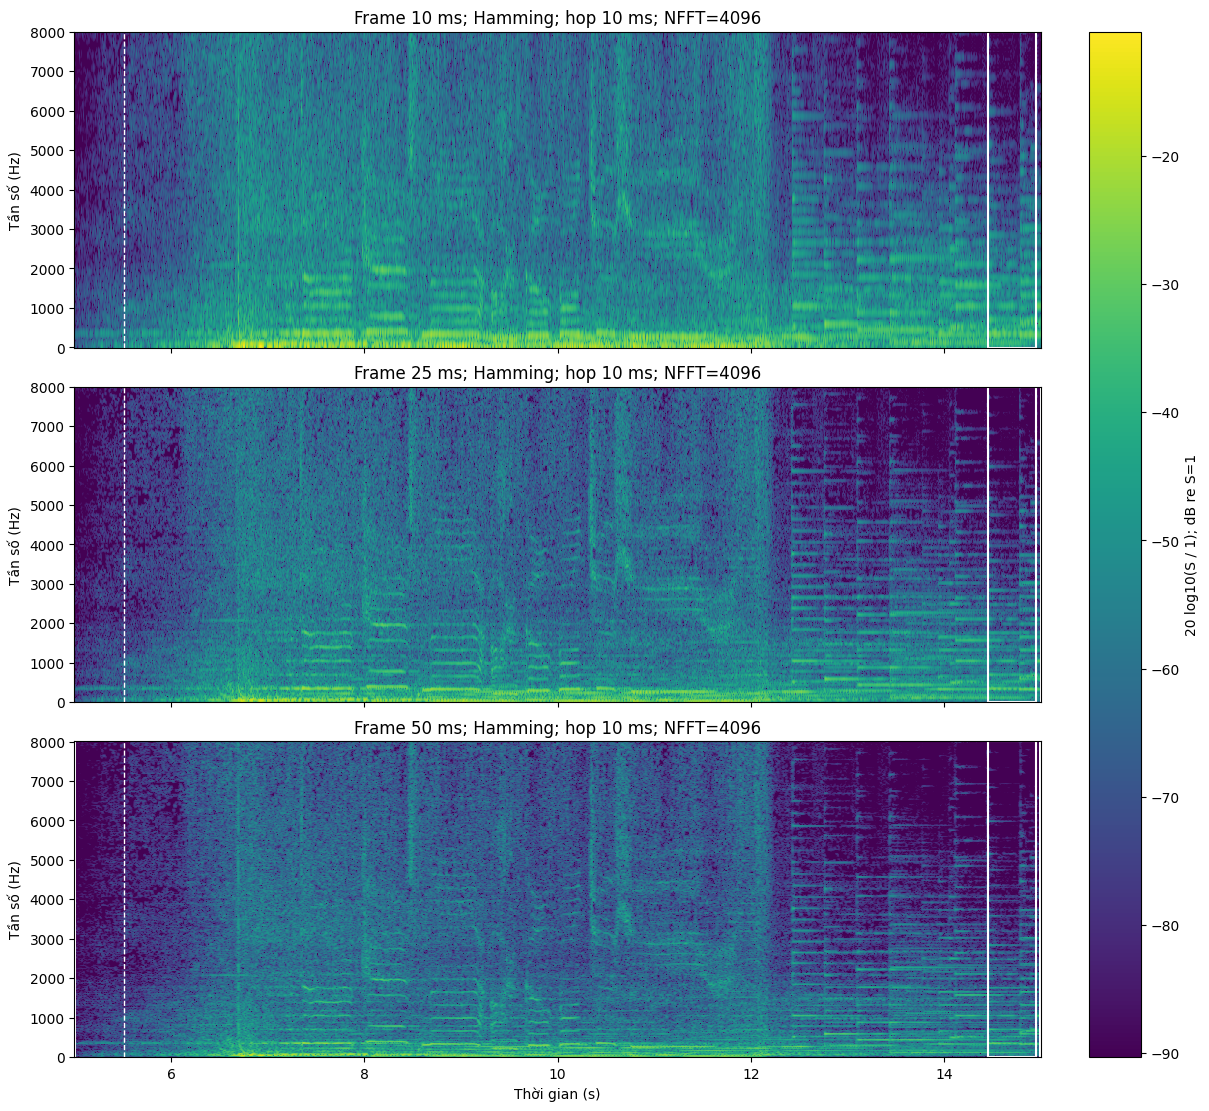

,frame_ms_requested,frame_samples,frame_ms_actual,hop_samples,overlap_percent,NFFT
0,10,441,10.000000,441,0.000000,4096
1,25,1102,24.988662,441,59.981851,4096
2,50,2205,50.000000,441,80.000000,4096


Ba spectrogram dùng cùng tín hiệu 5–15 s, NFFT=4096, hop 10 ms và chung khoảng màu [-90.31, -10.31] dB re S=1. Với frame 25 ms, khoảng 14.452–14.952 s có biến đổi phổ trung bình nhỏ nhất trên cửa sổ khoảng 0,5 s; tại 5.512 s có biến đổi phổ giữa hai frame lớn nhất, là ứng viên vùng chuyển tiếp nhanh để quan sát. Trong biểu diễn 25 ms, khoảng 96.17% tổng S² nằm dưới 2 kHz, giải thích các vùng màu mạnh ở dải thấp. Frame 10 ms dùng ít dữ liệu nên dải tần rộng hơn nhưng ít trộn các sự kiện gần nhau theo thời gian; frame 50 ms làm dải tần hẹp hơn và kéo dài ảnh hưởng của chuyển tiếp, còn 25 ms là mức trung gian.

In [5]:
STFT_START, STFT_DURATION, HOP_MS, NFFT_STFT = 5., 10., 10., 4096
stft_sig = x[round(STFT_START*Fs):round((STFT_START+STFT_DURATION)*Fs)]
specs, stft_rows = [], []
for frame_ms in [10,25,50]:
    L, H = round(frame_ms/1000*Fs), round(HOP_MS/1000*Fs)
    ff, tt, S = signal.spectrogram(stft_sig,fs=Fs,window=np.hamming(L),nperseg=L,
        noverlap=L-H,nfft=NFFT_STFT,detrend=False,mode='magnitude',scaling='spectrum')
    specs.append((frame_ms,ff,tt,S))
    stft_rows.append({'frame_ms_requested':frame_ms,'frame_samples':L,'frame_ms_actual':1000*L/Fs,
        'hop_samples':H,'overlap_percent':100*(L-H)/L,'NFFT':NFFT_STFT})
stft_table = pd.DataFrame(stft_rows)
_, ff, tt, S25 = specs[1]
normalized = S25/np.maximum(np.linalg.norm(S25,axis=0,keepdims=True),1e-12)
spectral_change = np.linalg.norm(np.diff(normalized,axis=1),axis=0)
event_index = int(np.argmax(spectral_change))
event_time = STFT_START+tt[event_index+1]
width = min(50,len(spectral_change))
stable_index = int(np.argmin(np.convolve(spectral_change,np.ones(width)/width,mode='valid')))
stable_start, stable_end = STFT_START+tt[stable_index], STFT_START+tt[stable_index+width]
mean_bandpower = np.mean(S25**2,axis=1)
lowband_percent = 100*mean_bandpower[ff<=2000].sum()/mean_bandpower.sum()
vmax = max(float(amplitude_db(item[3]).max()) for item in specs)
fig, axes = plt.subplots(3,1,figsize=(12,11),sharex=True,sharey=True,layout='constrained')
for ax,(frame_ms,ff,tt,S) in zip(axes,specs):
    mask = ff<=8000
    mesh=ax.pcolormesh(tt+STFT_START,ff[mask],amplitude_db(S[mask]),shading='auto',vmin=vmax-80,vmax=vmax)
    ax.set_title(f'Frame {frame_ms} ms; Hamming; hop {HOP_MS:g} ms; NFFT={NFFT_STFT}')
    ax.set_ylabel('Tần số (Hz)')
    ax.grid(False)
    ax.axvline(event_time,color='white',ls='--',lw=1)
    ax.axvspan(stable_start,stable_end,facecolor='none',edgecolor='white',lw=1.5)
axes[-1].set_xlabel('Thời gian (s)')
fig.colorbar(mesh,ax=list(axes),label='20 log10(S / 1); dB re S=1')
fig.savefig(FIG_DIR/'D_spectrogram_frames.png',dpi=140,bbox_inches='tight')
generated_figures.append('D_spectrogram_frames.png')
display(fig)
plt.close(fig)
stft_table.to_csv(OUTPUT_DIR/'stft_parameters.csv',index=False)
display(stft_table)
section('D. STFT và thay đổi thời gian–tần số',
    f'Ba spectrogram dùng cùng tín hiệu 5–15 s, NFFT={NFFT_STFT}, hop 10 ms và chung khoảng màu [{vmax-80:.2f}, {vmax:.2f}] dB re S=1. '
    f'Với frame 25 ms, khoảng {stable_start:.3f}–{stable_end:.3f} s có biến đổi phổ trung bình nhỏ nhất trên cửa sổ khoảng 0,5 s; '
    f'tại {event_time:.3f} s có biến đổi phổ giữa hai frame lớn nhất, là ứng viên vùng chuyển tiếp nhanh để quan sát. '
    f'Trong biểu diễn 25 ms, khoảng {lowband_percent:.2f}% tổng S² nằm dưới 2 kHz, giải thích các vùng màu mạnh ở dải thấp. '
    'Frame 10 ms dùng ít dữ liệu nên dải tần rộng hơn nhưng ít trộn các sự kiện gần nhau theo thời gian; frame 50 ms làm dải tần hẹp hơn và kéo dài ảnh hưởng của chuyển tiếp, còn 25 ms là mức trung gian.',
    tables=[stft_table],figures=[('D_spectrogram_frames.png','Giữ tín hiệu, hop, NFFT, cửa sổ và thang màu. Vạch trắng nét đứt: biến đổi phổ lớn nhất; khung trắng: khoảng ổn định tương đối.')])


## E. Rectangular và Hamming
Cùng frame thực 25 ms và NFFT=8192. Thêm đáp ứng của chính cửa sổ để đo
main-lobe/side-lobe, tránh nhầm một thành phần âm thanh thật với spectral leakage.


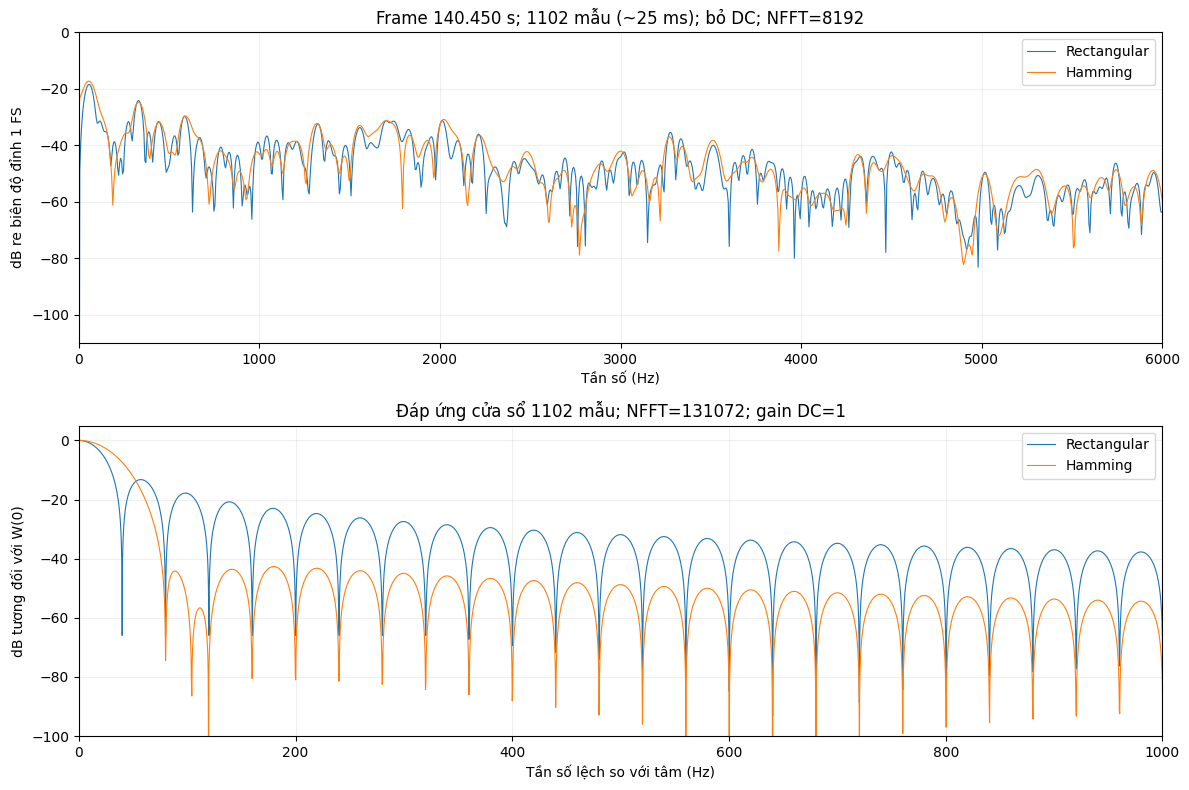

,window,samples,main_lobe_null_to_null_Hz,max_side_lobe_relative_dB
0,Rectangular,1102,80.076599,-13.261478
1,Hamming,1102,160.153198,-42.674471


Trên cùng frame 140.450 s, cả hai phổ dùng 1102 mẫu, NFFT=8192 và hiệu chỉnh theo tổng cửa sổ để so sánh biên độ. Đo trên đáp ứng cửa sổ cho thấy main-lobe Rectangular rộng khoảng 80.08 Hz, còn Hamming khoảng 160.15 Hz theo khoảng cách giữa hai cực tiểu đầu tiên. Side-lobe lớn nhất tương ứng -13.26 và -42.67 dB tương đối: Hamming giảm rò phổ nhưng làm các thành phần gần nhau dễ chồng lấn main-lobe. Đáp ứng cửa sổ bổ sung bằng chứng định lượng; không quy mọi gợn trên phổ âm thanh thực cho leakage.

In [6]:
L = round(.025*Fs)
FRAME_START = FFT_START + .2
frame = x[round(FRAME_START*Fs):round(FRAME_START*Fs)+L]
frame = frame-frame.mean()
NFFT_WINDOW = 8192
fig, axes = plt.subplots(2,1,figsize=(12,8))
window_rows = []
for name,weights in [('Rectangular',np.ones(L)),('Hamming',np.hamming(L))]:
    ff, aa = amplitude_spectrum(frame,Fs,NFFT_WINDOW,window=name.lower())
    axes[0].plot(ff,amplitude_db(aa),label=name,lw=.8)
    wf = np.fft.rfftfreq(131072,1/Fs)
    wm = np.abs(np.fft.rfft(weights,n=131072))/weights.sum()
    minima,_ = signal.find_peaks(-wm)
    first_minimum = int(minima[0])
    sidelobe_db = float(amplitude_db(wm[first_minimum:]).max())
    window_rows.append({'window':name,'samples':L,'main_lobe_null_to_null_Hz':2*wf[first_minimum],
        'max_side_lobe_relative_dB':sidelobe_db})
    axes[1].plot(wf,amplitude_db(wm),label=name,lw=.8)
axes[0].set(xlim=(0,6000),ylim=(-110,0),xlabel='Tần số (Hz)',ylabel='dB re biên độ đỉnh 1 FS',
    title=f'Frame {FRAME_START:.3f} s; {L} mẫu (~25 ms); bỏ DC; NFFT={NFFT_WINDOW}')
axes[1].set(xlim=(0,1000),ylim=(-100,5),xlabel='Tần số lệch so với tâm (Hz)',ylabel='dB tương đối với W(0)',
    title=f'Đáp ứng cửa sổ {L} mẫu; NFFT=131072; gain DC=1')
for ax in axes:
    ax.legend()
save_figure('E_windows.png',fig)
window_table = pd.DataFrame(window_rows)
window_table.to_csv(OUTPUT_DIR/'window_metrics.csv',index=False)
display(window_table)
r, h = window_rows
section('E. Thí nghiệm cửa sổ',
    f'Trên cùng frame {FRAME_START:.3f} s, cả hai phổ dùng {L} mẫu, NFFT={NFFT_WINDOW} và hiệu chỉnh theo tổng cửa sổ để so sánh biên độ. '
    f'Đo trên đáp ứng cửa sổ cho thấy main-lobe Rectangular rộng khoảng {r["main_lobe_null_to_null_Hz"]:.2f} Hz, '
    f'còn Hamming khoảng {h["main_lobe_null_to_null_Hz"]:.2f} Hz theo khoảng cách giữa hai cực tiểu đầu tiên. '
    f'Side-lobe lớn nhất tương ứng {r["max_side_lobe_relative_dB"]:.2f} và {h["max_side_lobe_relative_dB"]:.2f} dB tương đối: '
    'Hamming giảm rò phổ nhưng làm các thành phần gần nhau dễ chồng lấn main-lobe. '
    'Đáp ứng cửa sổ bổ sung bằng chứng định lượng; không quy mọi gợn trên phổ âm thanh thực cho leakage.',
    tables=[window_table],figures=[('E_windows.png','Phổ frame thực và đáp ứng hai cửa sổ; cùng tham số trong mỗi phép so sánh.')])


## F. FIR low-pass 2 kHz và high-pass 300 Hz
201 taps (bậc 200), Hamming. Audio xuất là đầu ra nhân quả của lfilter.
Riêng so sánh phổ và nghe trong notebook bù trễ 100 mẫu để khớp cùng sự kiện.


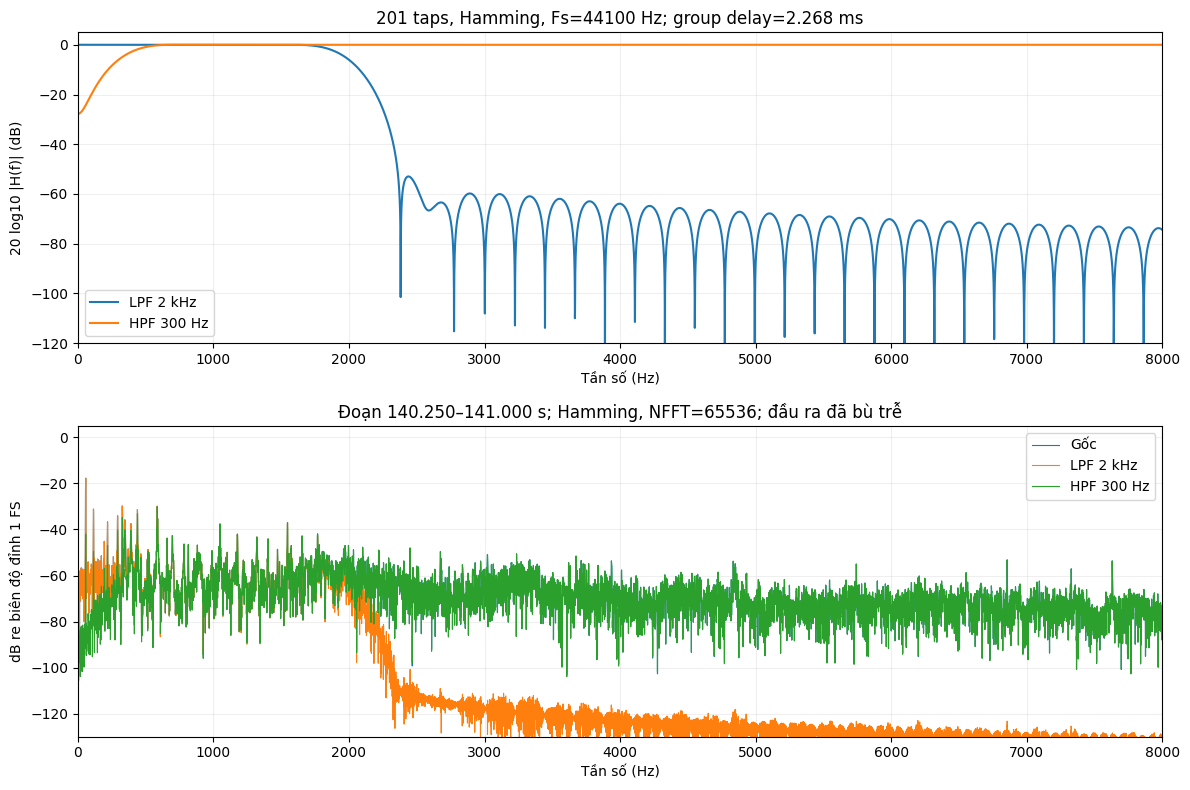

,filter,taps,order,group_delay_ms,stopband_used_Hz,worst_stopband_gain_dB
0,LPF 2 kHz,201,200,2.267574,>=2500,-57.401790
1,HPF 300 Hz,201,200,2.267574,0..100,-20.035129


**Gốc — 140.25–144.25 s; không tự tăng âm lượng**

**LPF, bù trễ — 140.25–144.25 s; không tự tăng âm lượng**

**HPF, bù trễ — 140.25–144.25 s; không tự tăng âm lượng**

Hai bộ lọc đều dài 201 taps, bậc 200, có group delay 100 mẫu = 2.267574 ms. Gain lớn nhất trong stopband đo được là -57.40 dB cho LPF ở ≥2,5 kHz và -20.04 dB cho HPF ở 0–100 Hz; không coi cutoff là vách cắt lý tưởng. Phổ LPF giảm dải cao và HPF giảm dải thấp phù hợp với H(f); các đường dùng chung chuẩn 1 FS và đầu ra được bù trễ khi so sánh, còn WAV lưu đầu ra nhân quả. Dự đoán khi nghe: LPF làm âm kém sáng do mất thành phần cao, HPF giảm tiếng trầm/ù và có thể làm giọng mỏng hơn; đây chưa phải kết quả khảo sát người nghe.

In [7]:
NUMTAPS, LP_CUTOFF, HP_CUTOFF = 201, 2000, 300
b_lp = signal.firwin(NUMTAPS,LP_CUTOFF,fs=Fs,window='hamming')
b_hp = signal.firwin(NUMTAPS,HP_CUTOFF,fs=Fs,window='hamming',pass_zero=False)
delay = (NUMTAPS-1)//2
group_delay_ms = 1000*delay/Fs
y_lp, y_hp = signal.lfilter(b_lp,[1.],x), signal.lfilter(b_hp,[1.],x)
write_audio('filtered_lpf_2k.wav',y_lp,Fs)
write_audio('filtered_hpf_300Hz.wav',y_hp,Fs)
pd.DataFrame({'tap':np.arange(NUMTAPS),'LPF_2k':b_lp,'HPF_300Hz':b_hp}).to_csv(OUTPUT_DIR/'fir_coefficients.csv',index=False)
aligned = {}
for name,coefficients in [('LPF 2 kHz',b_lp),('HPF 300 Hz',b_hp)]:
    aligned[name] = signal.lfilter(coefficients,[1.],np.pad(x,(0,delay)))[delay:delay+len(x)]
fig,axes = plt.subplots(2,1,figsize=(12,8))
filter_rows = []
for name,coefficients in [('LPF 2 kHz',b_lp),('HPF 300 Hz',b_hp)]:
    ff,hh = signal.freqz(coefficients,worN=32768,fs=Fs)
    axes[0].plot(ff,amplitude_db(np.abs(hh)),label=name)
    stop = ff>=2500 if name.startswith('LPF') else ff<=100
    filter_rows.append({'filter':name,'taps':NUMTAPS,'order':NUMTAPS-1,'group_delay_ms':group_delay_ms,
        'stopband_used_Hz':'>=2500' if name.startswith('LPF') else '0..100',
        'worst_stopband_gain_dB':float(amplitude_db(np.abs(hh[stop])).max())})
FILTER_START = FFT_START
a, b = round(FILTER_START*Fs), round((FILTER_START+.75)*Fs)
for name,values in [('Gốc',x),*aligned.items()]:
    ff,aa = amplitude_spectrum(values[a:b],Fs,65536)
    axes[1].plot(ff,amplitude_db(aa),label=name,lw=.8)
axes[0].set(xlim=(0,8000),ylim=(-120,5),xlabel='Tần số (Hz)',ylabel='20 log10 |H(f)| (dB)',
    title=f'201 taps, Hamming, Fs={Fs} Hz; group delay={group_delay_ms:.3f} ms')
axes[1].set(xlim=(0,8000),ylim=(-130,5),xlabel='Tần số (Hz)',ylabel='dB re biên độ đỉnh 1 FS',
    title=f'Đoạn {FILTER_START:.3f}–{FILTER_START+.75:.3f} s; Hamming, NFFT=65536; đầu ra đã bù trễ')
for ax in axes:
    ax.legend()
save_figure('F_filter_response_spectrum.png',fig)
filter_table = pd.DataFrame(filter_rows)
filter_table.to_csv(OUTPUT_DIR/'filter_metrics.csv',index=False)
display(filter_table)
play_comparison([('Gốc',x,Fs),('LPF, bù trễ',aligned['LPF 2 kHz'],Fs),('HPF, bù trễ',aligned['HPF 300 Hz'],Fs)],FFT_START)
section('F. Lọc số FIR',
    f'Hai bộ lọc đều dài {NUMTAPS} taps, bậc {NUMTAPS-1}, có group delay {delay} mẫu = {group_delay_ms:.6f} ms. '
    f'Gain lớn nhất trong stopband đo được là {filter_rows[0]["worst_stopband_gain_dB"]:.2f} dB cho LPF ở ≥2,5 kHz '
    f'và {filter_rows[1]["worst_stopband_gain_dB"]:.2f} dB cho HPF ở 0–100 Hz; không coi cutoff là vách cắt lý tưởng. '
    'Phổ LPF giảm dải cao và HPF giảm dải thấp phù hợp với H(f); các đường dùng chung chuẩn 1 FS và đầu ra được bù trễ khi so sánh, còn WAV lưu đầu ra nhân quả. '
    'Dự đoán khi nghe: LPF làm âm kém sáng do mất thành phần cao, HPF giảm tiếng trầm/ù và có thể làm giọng mỏng hơn; đây chưa phải kết quả khảo sát người nghe.',
    tables=[filter_table],figures=[('F_filter_response_spectrum.png','Đáp ứng bộ lọc và phổ cùng chuẩn biên độ, cùng sự kiện sau bù trễ.')],
    audio_files=['input_mono_PCM16.wav','filtered_lpf_2k.wav','filtered_hpf_300Hz.wav'])


## G1. Lượng tử hóa 4/8/16 bit và SNR đo lại từ WAV
Dùng lưới PCM đều: Δ=2/2^B; q=clip(round(x/Δ), −2^(B−1), 2^(B−1)−1)·Δ.
Lưới có 2^B mức từ −1 đến 1−Δ, trùng các mức lưu PCM, tránh lượng tử hóa hai lần.
Khác công thức minh họa qmax trong đề, quy ước này dùng đủ 2^B mức và giải thích rõ ở báo cáo.


,B_bit,step_FS,levels_available,SNR_array_dB,SNR_WAV_dB,noise_RMS,SNR_model_dB,max_WAV_array_error
0,4,0.125000,16,12.176716,12.176716,0.035214,11.964707,0.0
1,8,0.007812,256,36.172796,36.172796,0.002223,36.047106,0.0
2,16,0.000031,65536,84.295473,84.295473,0.000009,84.211905,0.0


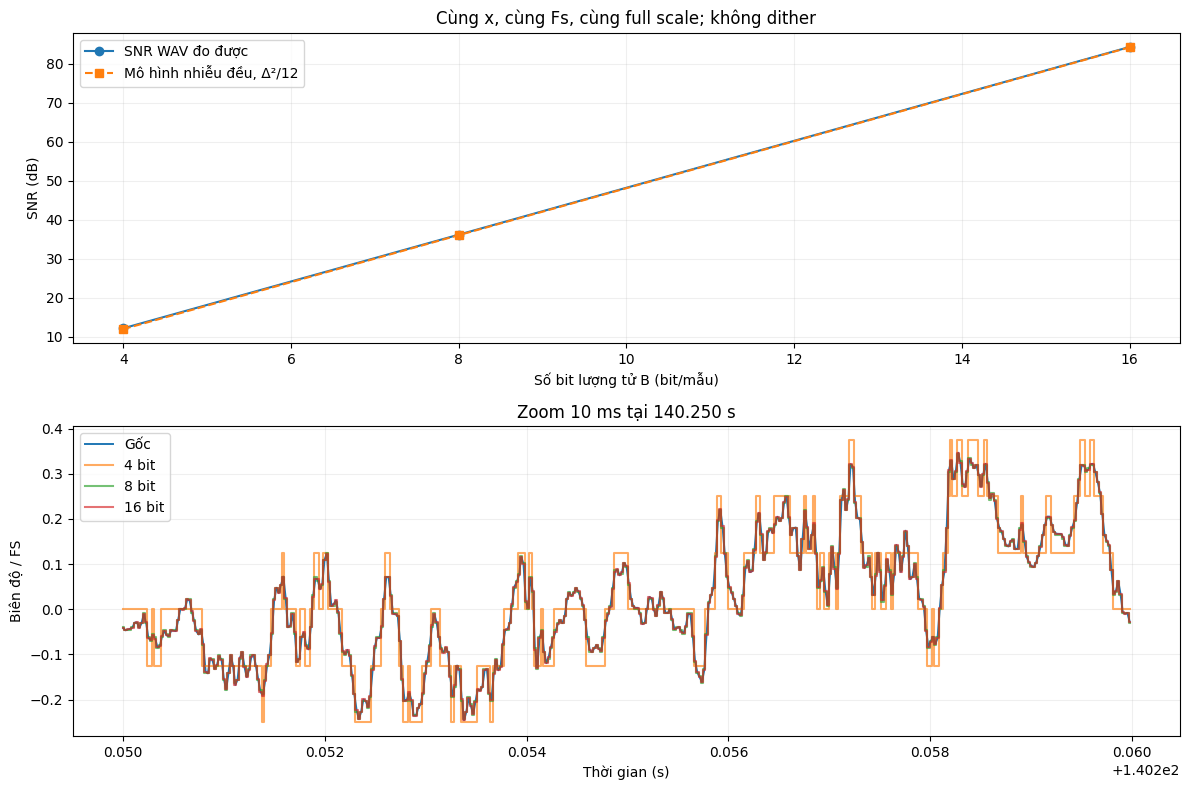

**Gốc — 140.25–144.25 s; không tự tăng âm lượng**

**4 bit — 140.25–144.25 s; không tự tăng âm lượng**

**8 bit — 140.25–144.25 s; không tự tăng âm lượng**

**16 bit — 140.25–144.25 s; không tự tăng âm lượng**

Thí nghiệm dùng bộ lượng tử PCM với Δ = 2/2^B và 2^B mức từ −1 đến 1−Δ; khác công thức qmax đối xứng trong ví dụ đề bài, lựa chọn này khớp chính xác lưới của WAV PCM. SNR đo được ở 4/8/16 bit lần lượt 12.177, 36.173, 84.295 dB, tăng 23.996 dB khi thêm 4 bit và 48.123 dB khi thêm 8 bit, gần xu hướng 6 dB/bit. Đọc lại WAV cho sai khác bằng 0 so với mảng lượng tử, nên SNR trong bảng thực sự đại diện file xuất; bản 4-bit lưu trong PCM16 chỉ mô phỏng mức lượng tử, không tiết kiệm dung lượng như dữ liệu đóng gói 4-bit. Dự đoán nhiễu/méo lượng tử dễ nhận ra ở phần âm nhỏ hoặc đuôi âm do tỷ lệ sai số/tín hiệu lớn; im lặng số đúng bằng 0 vẫn lượng tử thành 0 khi không dither.

In [8]:
def quantize_pcm(values,B):
    scale = 2**(B-1)
    return np.clip(np.rint(np.asarray(values)*scale),-scale,scale-1)/scale

quant_rows, quant_signals = [], {}
for bits in [4,8,16]:
    q = quantize_pcm(x,bits)
    quant_signals[bits] = q
    name = f'quantized_{bits}bit.wav' if bits!=4 else 'quantized_4bit_levels_in_PCM16.wav'
    path = write_audio(name,q,Fs,subtype='PCM_U8' if bits==8 else 'PCM_16')
    decoded, read_fs = sf.read(str(path),dtype='float64')
    assert read_fs==Fs and np.array_equal(decoded,q), 'WAV phải giữ đúng các mức lượng tử đã tính.'
    quant_rows.append({'B_bit':bits,'step_FS':2/2**bits,'levels_available':2**bits,
        'SNR_array_dB':snr(x,q),'SNR_WAV_dB':snr(x,decoded),'noise_RMS':rms(q-x),
        'SNR_model_dB':6.020599913*bits+4.771212547+20*np.log10(rms_full),
        'max_WAV_array_error':np.max(np.abs(decoded-q))})
quant_table = pd.DataFrame(quant_rows)
quant_table.to_csv(OUTPUT_DIR/'quantization_snr.csv',index=False)
display(quant_table)
fig,axes = plt.subplots(2,1,figsize=(12,8))
axes[0].plot(quant_table.B_bit,quant_table.SNR_WAV_dB,'o-',label='SNR WAV đo được')
axes[0].plot(quant_table.B_bit,quant_table.SNR_model_dB,'s--',label='Mô hình nhiễu đều, Δ²/12')
axes[0].set(xlabel='Số bit lượng tử B (bit/mẫu)',ylabel='SNR (dB)',title='Cùng x, cùng Fs, cùng full scale; không dither')
a,b = round(FFT_START*Fs),round((FFT_START+.01)*Fs)
axes[1].plot(np.arange(a,b)/Fs,x[a:b],label='Gốc',lw=1.4)
for bits in [4,8,16]:
    axes[1].step(np.arange(a,b)/Fs,quant_signals[bits][a:b],where='mid',label=f'{bits} bit',alpha=.65)
axes[1].set(xlabel='Thời gian (s)',ylabel='Biên độ / FS',title=f'Zoom 10 ms tại {FFT_START:.3f} s')
for ax in axes:
    ax.legend()
save_figure('G1_quantization.png',fig)
play_comparison([('Gốc',x,Fs)]+[(f'{bits} bit',quant_signals[bits],Fs) for bits in [4,8,16]],FFT_START)
section('G1. Lượng tử hóa và SNR',
    'Thí nghiệm dùng bộ lượng tử PCM với Δ = 2/2^B và 2^B mức từ −1 đến 1−Δ; '
    'khác công thức qmax đối xứng trong ví dụ đề bài, lựa chọn này khớp chính xác lưới của WAV PCM. '
    f'SNR đo được ở 4/8/16 bit lần lượt {", ".join(f"{v:.3f}" for v in quant_table.SNR_WAV_dB)} dB, '
    f'tăng {quant_table.SNR_WAV_dB.iloc[1]-quant_table.SNR_WAV_dB.iloc[0]:.3f} dB khi thêm 4 bit và '
    f'{quant_table.SNR_WAV_dB.iloc[2]-quant_table.SNR_WAV_dB.iloc[1]:.3f} dB khi thêm 8 bit, gần xu hướng 6 dB/bit. '
    'Đọc lại WAV cho sai khác bằng 0 so với mảng lượng tử, nên SNR trong bảng thực sự đại diện file xuất; bản 4-bit lưu trong PCM16 chỉ mô phỏng mức lượng tử, không tiết kiệm dung lượng như dữ liệu đóng gói 4-bit. '
    'Dự đoán nhiễu/méo lượng tử dễ nhận ra ở phần âm nhỏ hoặc đuôi âm do tỷ lệ sai số/tín hiệu lớn; im lặng số đúng bằng 0 vẫn lượng tử thành 0 khi không dither.',
    tables=[quant_table],figures=[('G1_quantization.png','SNR đo trực tiếp từ WAV và dạng sóng lượng tử; cùng full scale.')],
    audio_files=['quantized_4bit_levels_in_PCM16.wav','quantized_8bit.wav','quantized_16bit.wav'])


## G2. Resampling và kiểm tra chống aliasing
resample_poly thực hiện nội suy/lọc FIR/giảm mẫu. Cùng khoảng thời gian và
chuẩn biên độ cho phổ so sánh. Thêm sinusoid kiểm soát để định lượng ảnh phổ alias.


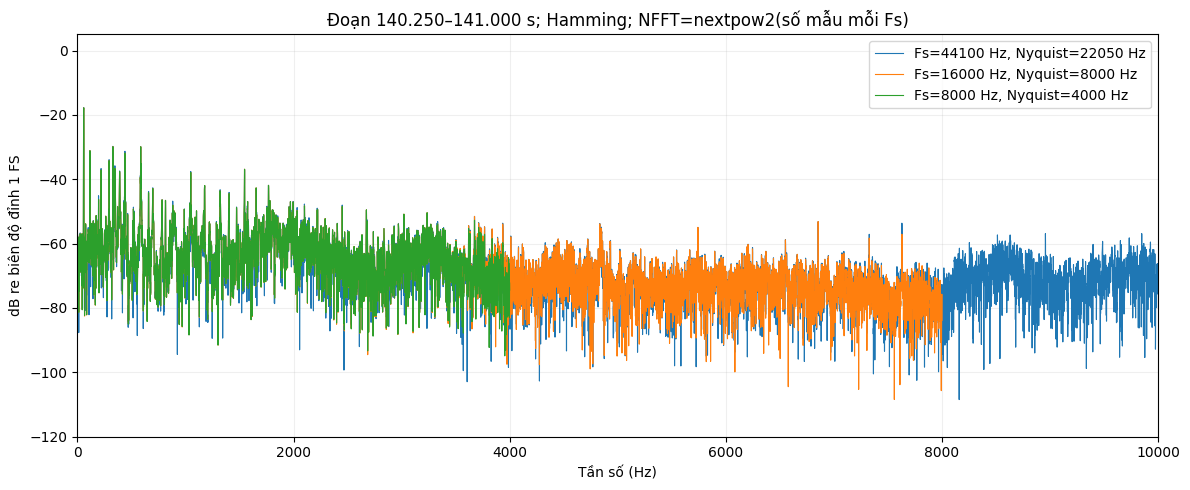

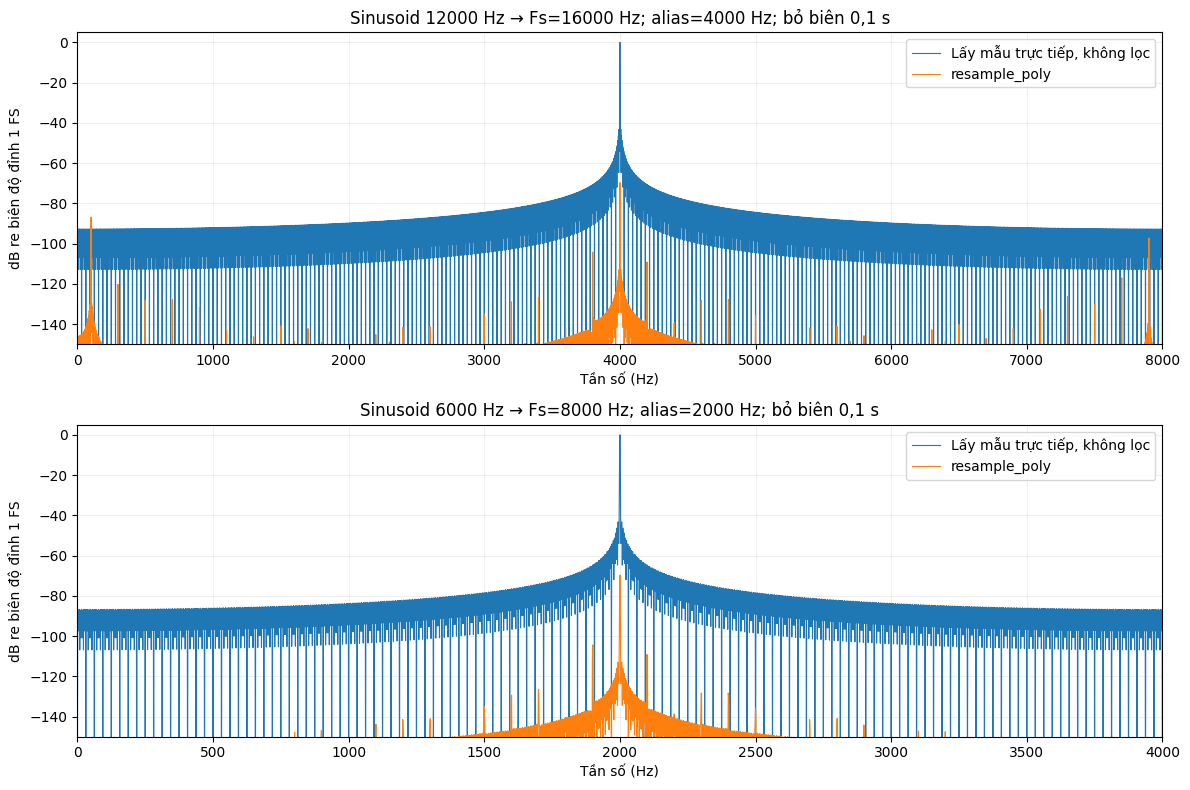

,Fs_Hz,samples,duration_s,Nyquist_Hz,Peak
0,16000,3429495,214.343437,8000.0,0.841624
1,8000,1714748,214.343500,4000.0,0.770467


,target_Fs_Hz,input_tone_Hz,alias_Hz,alias_amp_without_filter,alias_amp_resample_poly,alias_change_dB
0,16000,12000,4000.0,1.0,0.000327,-69.702768
1,8000,6000,2000.0,1.0,0.000327,-69.702768


**44100 Hz — 140.25–144.25 s; không tự tăng âm lượng**

**16000 Hz — 140.25–144.25 s; không tự tăng âm lượng**

**8000 Hz — 140.25–144.25 s; không tự tăng âm lượng**

Sau resample, Nyquist giảm còn 8 kHz và 4 kHz; thời lượng chỉ khác ở mức làm tròn một mẫu, còn phổ dùng cùng chuẩn biên độ và cùng khoảng thời gian. Trong thí nghiệm sinusoid kiểm soát, tone 12 kHz sẽ gập về 4 kHz khi lấy mẫu trực tiếp ở 16 kHz, và tone 6 kHz gập về 2 kHz khi lấy mẫu trực tiếp ở 8 kHz; resample_poly giảm biên độ alias tương ứng 69.70 và 69.70 dB sau khi bỏ vùng biên. Kết quả cho thấy lọc chống aliasing có tác dụng, nhưng FIR hữu hạn không đảm bảo alias bằng 0 tuyệt đối ở mọi tần số và thí nghiệm tone không đo toàn bộ alias của bản ghi thực. Dự đoán bản 8 kHz kém sáng/rõ chi tiết cao hơn bản 16 kHz, đặc biệt ở thành phần trên 4 kHz; mức giảm chất lượng cảm nhận cần xác nhận bằng các trình phát cùng âm lượng trong notebook.

In [9]:
def resample_to(values,fs_old,fs_new):
    divisor = math.gcd(int(fs_old),int(fs_new))
    return signal.resample_poly(values,fs_new//divisor,fs_old//divisor)

resampled = {Fs:x}
resample_rows = []
for target in [16000,8000]:
    values = resample_to(x,Fs,target)
    resampled[target] = values
    write_audio(f'speech_resampled_{target//1000}kHz.wav',values,target)
    resample_rows.append({'Fs_Hz':target,'samples':len(values),'duration_s':len(values)/target,
        'Nyquist_Hz':target/2,'Peak':np.max(np.abs(values))})
resample_table = pd.DataFrame(resample_rows)
fig,ax = plt.subplots(figsize=(12,5))
for fs,values in resampled.items():
    aa,bb = round(FFT_START*fs),round((FFT_START+.75)*fs)
    ff,mm = amplitude_spectrum(values[aa:bb],fs)
    ax.plot(ff,amplitude_db(mm),label=f'Fs={fs} Hz, Nyquist={fs/2:g} Hz',lw=.8)
ax.set(xlim=(0,10000),ylim=(-120,5),xlabel='Tần số (Hz)',ylabel='dB re biên độ đỉnh 1 FS',
    title=f'Đoạn {FFT_START:.3f}–{FFT_START+.75:.3f} s; Hamming; NFFT=nextpow2(số mẫu mỗi Fs)')
ax.legend()
save_figure('G2_resampling.png',fig)

# Controlled continuous sinusoid: sample directly at target Fs (no prefilter)
# versus sampling at Fs=44100 then using the antialiasing resampler.
alias_rows = []
fig,axes = plt.subplots(2,1,figsize=(12,8))
for ax,target,tone in zip(axes,[16000,8000],[12000,6000]):
    source_t = np.arange(Fs)/Fs
    source = np.sin(2*np.pi*tone*source_t)
    protected = resample_to(source,Fs,target)
    target_t = np.arange(len(protected))/target
    unprotected = np.sin(2*np.pi*tone*target_t)
    alias_f = abs((tone+target/2)%target-target/2)
    trim = slice(round(.1*target),round(.9*target))
    ttrim = target_t[trim]
    def tone_amplitude(values):
        return 2*abs(np.mean(values[trim]*np.exp(-2j*np.pi*alias_f*ttrim)))
    amp_before,amp_after = tone_amplitude(unprotected),tone_amplitude(protected)
    alias_rows.append({'target_Fs_Hz':target,'input_tone_Hz':tone,'alias_Hz':alias_f,
        'alias_amp_without_filter':amp_before,'alias_amp_resample_poly':amp_after,
        'alias_change_dB':20*np.log10(max(amp_after,1e-15)/amp_before)})
    for label,values in [('Lấy mẫu trực tiếp, không lọc',unprotected),('resample_poly',protected)]:
        ff,mm = amplitude_spectrum(values[trim],target)
        ax.plot(ff,amplitude_db(mm),label=label,lw=.8)
    ax.set(xlim=(0,target/2),ylim=(-150,5),xlabel='Tần số (Hz)',ylabel='dB re biên độ đỉnh 1 FS',
        title=f'Sinusoid {tone} Hz → Fs={target} Hz; alias={alias_f:g} Hz; bỏ biên 0,1 s')
    ax.legend()
save_figure('G2_alias_control.png',fig)
alias_table = pd.DataFrame(alias_rows)
resample_table.to_csv(OUTPUT_DIR/'resampling_metrics.csv',index=False)
alias_table.to_csv(OUTPUT_DIR/'alias_control.csv',index=False)
display(resample_table,alias_table)
play_comparison([(f'{fs} Hz',values,fs) for fs,values in resampled.items()],FFT_START)
section('G2. Resampling 16 kHz và 8 kHz',
    'Sau resample, Nyquist giảm còn 8 kHz và 4 kHz; thời lượng chỉ khác ở mức làm tròn một mẫu, còn phổ dùng cùng chuẩn biên độ và cùng khoảng thời gian. '
    f'Trong thí nghiệm sinusoid kiểm soát, tone 12 kHz sẽ gập về 4 kHz khi lấy mẫu trực tiếp ở 16 kHz, '
    f'và tone 6 kHz gập về 2 kHz khi lấy mẫu trực tiếp ở 8 kHz; resample_poly giảm biên độ alias tương ứng '
    f'{-alias_rows[0]["alias_change_dB"]:.2f} và {-alias_rows[1]["alias_change_dB"]:.2f} dB sau khi bỏ vùng biên. '
    'Kết quả cho thấy lọc chống aliasing có tác dụng, nhưng FIR hữu hạn không đảm bảo alias bằng 0 tuyệt đối ở mọi tần số và thí nghiệm tone không đo toàn bộ alias của bản ghi thực. '
    'Dự đoán bản 8 kHz kém sáng/rõ chi tiết cao hơn bản 16 kHz, đặc biệt ở thành phần trên 4 kHz; mức giảm chất lượng cảm nhận cần xác nhận bằng các trình phát cùng âm lượng trong notebook.',
    tables=[resample_table,alias_table],figures=[('G2_resampling.png','Phổ bản gốc và hai sampling rate.'),
    ('G2_alias_control.png','Thí nghiệm phụ có kiểm soát, cùng sinusoid và cùng mức biên độ trước khi đổi Fs.')],
    audio_files=['speech_resampled_16kHz.wav','speech_resampled_8kHz.wav'])


## G3. PCM, MP3, bit rate, kích thước và compression ratio
So sánh cùng Fs, số kênh, thời lượng. MP3 là tệp đầu vào đã có;
WAV giải mã không khôi phục thông tin đã mất và không phải bản thu lossless gốc.


,Đại lượng,Giá trị,Đơn vị
0,PCM bitrate,1.411200e+06,bit/s
1,MP3 average file bitrate,1.380114e+05,bit/s
2,PCM theoretical payload,3.781018e+07,byte
3,WAV actual size,3.781022e+07,byte
4,MP3 actual size,3.697728e+06,byte
5,PCM/MP3 ratio,1.022525e+01,:1
6,Saving,9.022028e+01,%


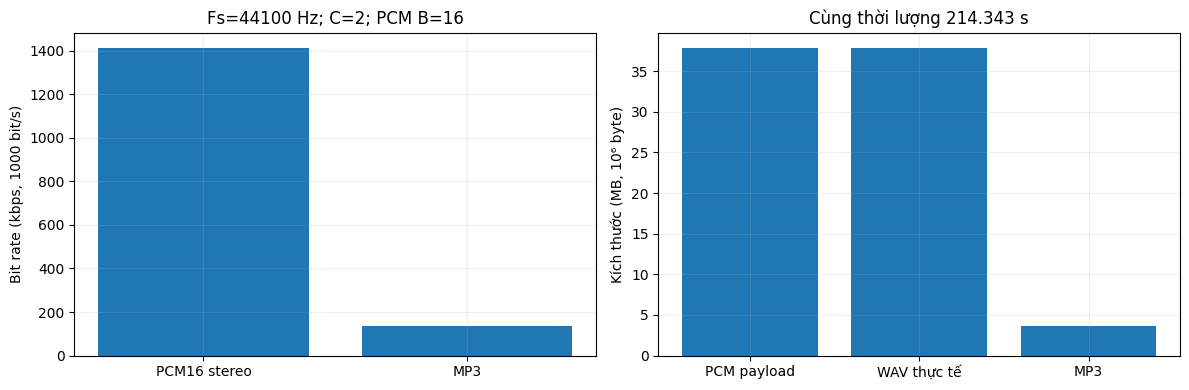

PCM16 2 kênh tại 44100 Hz có R = Fs × B × C = 1,411,200 bit/s, payload 37,810,176 byte cho 214.343401 s; WAV thực tế lớn hơn payload 44 byte do phần chứa/header. MP3 có kích thước 3,697,728 byte và bitrate trung bình ước lượng 138.011 kbps, tương ứng tỷ lệ PCM/MP3 = 10.225245:1 và tiết kiệm 90.2203%. Ước lượng bitrate từ toàn tệp bao gồm metadata; PCM và MP3 được so sánh với cùng số kênh, Fs và thời lượng, không so stereo với mono. Giải mã MP3 sang WAV chỉ đổi biểu diễn lưu trữ; do không có bản thu lossless trước mã hóa, không thể đo tổn thất codec hoặc kết luận WAV khôi phục/chất lượng cao hơn MP3 từ phép so sánh này.

In [10]:
pcm_bitrate = Fs*PCM_BITS*channels
pcm_size = len(x_multi_raw)*channels*PCM_BITS//8
mp3_size = INPUT_FILE.stat().st_size
mp3_bitrate = mp3_size*8/duration
pcm_path = write_audio('input_decoded_PCM16.wav',x_multi,Fs)
compression_ratio = pcm_size/mp3_size
saving_percent = (1-mp3_size/pcm_size)*100
coding_table = pd.DataFrame([
    ['PCM bitrate',pcm_bitrate,'bit/s'],['MP3 average file bitrate',mp3_bitrate,'bit/s'],
    ['PCM theoretical payload',pcm_size,'byte'],['WAV actual size',pcm_path.stat().st_size,'byte'],
    ['MP3 actual size',mp3_size,'byte'],['PCM/MP3 ratio',compression_ratio,':1'],
    ['Saving',saving_percent,'%'],
],columns=['Đại lượng','Giá trị','Đơn vị'])
coding_table.to_csv(OUTPUT_DIR/'coding_comparison.csv',index=False)
display(coding_table)
fig,axes = plt.subplots(1,2,figsize=(12,4))
axes[0].bar(['PCM16 stereo','MP3'],[pcm_bitrate/1000,mp3_bitrate/1000])
axes[0].set(ylabel='Bit rate (kbps, 1000 bit/s)',title=f'Fs={Fs} Hz; C={channels}; PCM B=16')
axes[1].bar(['PCM payload','WAV thực tế','MP3'],[pcm_size/1e6,pcm_path.stat().st_size/1e6,mp3_size/1e6])
axes[1].set(ylabel='Kích thước (MB, 10⁶ byte)',title=f'Cùng thời lượng {duration:.3f} s')
save_figure('G3_coding.png',fig)
section('G3. Bit rate, kích thước và mức nén',
    f'PCM16 {channels} kênh tại {Fs} Hz có R = Fs × B × C = {pcm_bitrate:,} bit/s, '
    f'payload {pcm_size:,} byte cho {duration:.6f} s; WAV thực tế lớn hơn payload {pcm_path.stat().st_size-pcm_size} byte do phần chứa/header. '
    f'MP3 có kích thước {mp3_size:,} byte và bitrate trung bình ước lượng {mp3_bitrate/1000:.3f} kbps, '
    f'tương ứng tỷ lệ PCM/MP3 = {compression_ratio:.6f}:1 và tiết kiệm {saving_percent:.4f}%. '
    'Ước lượng bitrate từ toàn tệp bao gồm metadata; PCM và MP3 được so sánh với cùng số kênh, Fs và thời lượng, không so stereo với mono. '
    'Giải mã MP3 sang WAV chỉ đổi biểu diễn lưu trữ; do không có bản thu lossless trước mã hóa, không thể đo tổn thất codec hoặc kết luận WAV khôi phục/chất lượng cao hơn MP3 từ phép so sánh này.',
    tables=[coding_table],figures=[('G3_coding.png','Bitrate và kích thước: MB theo hệ thập phân; đối chiếu cùng cấu hình.')],
    audio_files=['input_decoded_PCM16.wav'])


## Câu hỏi báo cáo và xuất Markdown
Báo cáo được sinh từ số liệu vừa tính, không dùng kết quả chèn thủ công.
Các phát biểu về nghe được tách rõ khỏi phép đo khách quan.


In [11]:
answers = f'''## Trả lời 7 câu hỏi báo cáo

1. **Vì sao Fs = 44,1 kHz biểu diễn độc lập tới 22,05 kHz?** Sau lấy mẫu, exp(j2π(f+kFs)n/Fs) = exp(j2πfn/Fs), nên các tần số cách nhau bội Fs có cùng mẫu. Với tín hiệu thực, phần tần số âm là liên hợp của phần dương; dải độc lập là 0 đến Fs/2 = 22.050 Hz. Thành phần trên Nyquist gập vào dải này nếu không được lọc trước; tại đúng Nyquist còn có trường hợp pha không thể khôi phục đầy đủ, nên thực tế cần băng chuyển tiếp.

2. **NFFT từ 2048 lên 8192 với frame 25 ms:** Δf giảm từ 44100/2048 = {44100/2048:.6f} Hz xuống {44100/8192:.6f} Hz, tức lưới phổ dày hơn 4 lần. Frame vẫn khoảng 1102 mẫu (~25 ms), nên lượng thông tin và main-lobe do cửa sổ quyết định không thay đổi. Không thể dùng zero-padding để tách hai thành phần vốn bị chồng main-lobe.

3. **Hamming và leakage:** phép cắt đoạn tương đương nhân cửa sổ, nên phổ quan sát là phổ tín hiệu chập với phổ cửa sổ. Hamming làm nhỏ biên ở hai đầu frame và hạ side-lobe, giảm rò năng lượng sang các tần số khác. Đổi lại main-lobe rộng hơn Rectangular, làm hai đỉnh gần nhau khó phân tách; số đo ở phần E minh họa hai mặt của đánh đổi này.

4. **Độ trễ FIR:** (201−1)/2 = 100 mẫu, tương đương 100/44100 × 1000 = {100/44100*1000:.6f} ms. Trong xử lý offline có thể dịch để căn chỉnh, nhưng xử lý nhân quả thời gian thực phải chờ mẫu; tổng latency còn có buffering, frame, thiết bị và các khối nối tiếp. Khoảng 2,27 ms là nhỏ trong nhiều ứng dụng, nhưng vẫn đáng tính vào ngân sách trễ khi monitoring, tương tác hoặc ghép với tín hiệu trực tiếp.

5. **Ảnh hưởng của B và σx:** SNR_Q ≈ 6B + 4,77 − 20log10(Xmax/σx). Giữ Xmax và tín hiệu không đổi, thêm một bit tăng SNR khoảng 6 dB; nếu giảm RMS σx một nửa trong khi bước lượng tử không đổi, SNR giảm khoảng 6,02 dB. Với tín hiệu thực có im lặng, phân bố không đều, clipping hoặc tương quan sai số, mô hình nhiễu đều chỉ gần đúng; dùng SNR đo ở G1 để đánh giá dữ liệu thật.

6. **PCM 60 s và MP3 128 kbps:** PCM = 44100 × 16 × 2 × 60 / 8 = 10.584.000 byte = 10,584 MB ≈ {10584000/2**20:.3f} MiB. MP3 128.000 bit/s dài 60 s có payload xấp xỉ 960.000 byte = 0,960 MB, chưa tính header/metadata. Tỷ lệ = 11,025:1, tiết kiệm khoảng {(1-960000/10584000)*100:.4f}%; không nhầm MB thập phân với MiB.

7. **Hai trường hợp nghe tốt hơn không tương đương SNR cao hơn:** (a) Sai số được dồn vào vùng bị âm mạnh che lấp có thể ít nghe thấy hơn sai số nhỏ hơn nhưng nằm ở vùng tai nhạy; SNR năng lượng toàn dải không tính masking. (b) Dither trước lượng tử có thể làm tăng năng lượng nhiễu, giảm SNR nhưng làm méo lượng tử bớt có tính chu kỳ, giảm các vệt/âm giả khó chịu. Các ví dụ này giải thích giới hạn của SNR, không phải kết quả thử nghe đã thực hiện trên tệp hiện tại.
'''
display(Markdown(answers))

versions = {'python':platform.python_version(),'numpy':np.__version__,'scipy':scipy.__version__,
    'pandas':pd.__version__,'matplotlib':matplotlib.__version__,'soundfile':sf.__version__}
checks = {
    'fft_no_truncation':all(n>=len(fft_seg) for n in NFFT_LIST),
    'fft_at_least_three_peaks':len(peak_table)>=3,
    'quantized_wav_exact':bool((quant_table.max_WAV_array_error==0).all()),
    'resampling_duration_error_le_one_sample':all(abs(len(v)/fs-duration)<=1/fs for fs,v in resampled.items()),
    'fir_symmetric':bool(np.allclose(b_lp,b_lp[::-1]) and np.allclose(b_hp,b_hp[::-1])),
    'figures_exist':all((FIG_DIR/name).is_file() for name in generated_figures),
    'audio_exists':all((AUDIO_DIR/name).is_file() for name in generated_audio),
}
assert all(checks.values()), checks
audio_inventory = []
for name in generated_audio:
    ai=sf.info(str(AUDIO_DIR/name))
    audio_inventory.append({'file':name,'Fs_Hz':ai.samplerate,'channels':ai.channels,
        'frames':ai.frames,'subtype':ai.subtype,'size_bytes':(AUDIO_DIR/name).stat().st_size})
pd.DataFrame(audio_inventory).to_csv(OUTPUT_DIR/'audio_manifest.csv',index=False)
verification = {'checks':checks,'versions':versions,'input_sha256':hashlib.sha256(INPUT_FILE.read_bytes()).hexdigest(),
    'figures':generated_figures,'audio':audio_inventory,'FFT_START':FFT_START,'FFT_duration_s':len(fft_seg)/Fs,
    'STFT_fast_change_s':float(event_time),'STFT_stable_range_s':[float(stable_start),float(stable_end)]}
(OUTPUT_DIR/'verification.json').write_text(json.dumps(verification,ensure_ascii=False,indent=2),encoding='utf-8')

intro = f'''# CSE457 — Báo cáo Lab 1

**Phân tích và xử lý tín hiệu âm thanh số với datalab1.mp3**

Notebook: [CSE457_Lab1_VSCode_datalab1.ipynb](CSE457_Lab1_VSCode_datalab1.ipynb). Dữ liệu: [datalab1.mp3](datalab1.mp3).

Báo cáo này được tạo từ lần chạy notebook, đối chiếu phần A–G của *Lab 1.pdf*, trang 4–5; thí nghiệm độc lập và câu hỏi ở trang 9–10. Dữ liệu do người học cung cấp khác case study, vì vậy kết quả không phải tái tạo các con số của Western Cowboy Texas Music.mp3.

## Môi trường và quy ước

- Python {versions['python']}; NumPy {versions['numpy']}; SciPy {versions['scipy']}; SoundFile {versions['soundfile']}; Matplotlib {versions['matplotlib']}; pandas {versions['pandas']}.
- Đặt notebook và MP3 cùng thư mục, cài `python -m pip install -r requirements.txt`, chọn kernel rồi **Run All**.
- Mẫu tính toán float64. Biên độ chuẩn hóa theo full scale, RMS dBFS = 20log10(RMS/1); phổ một phía hiệu chỉnh tổng cửa sổ và ghi dB re biên độ đỉnh 1 FS. Spectrogram dùng dB re S=1 theo scaling spectrum; đáp ứng cửa sổ ghi relative dB, SNR ghi SNR dB.
- Không tự chuẩn hóa riêng từng tín hiệu khi so sánh mức. Trình phát notebook dùng `normalize=False` trên cùng đoạn; giữ cùng âm lượng thiết bị khi nghe.
- **Giới hạn nghe thử:** đã cung cấp audio và trình phát để so sánh; các mô tả cảm nhận là dự đoán dựa trên phổ/đáp ứng/nhiễu, chưa phải kết quả nghe chủ quan hoặc khảo sát người nghe. Không có bản thu lossless trước MP3 để đo tổn thất mã hóa.
'''
end = f'''## Kiểm tra khả năng tái lập và tệp kết quả

Các kiểm tra tự động đều đạt: FFT không cắt mẫu, ít nhất 3 đỉnh, WAV lượng tử giữ chính xác mảng tính toán, thời lượng resample sai khác không quá một mẫu, FIR đối xứng và tất cả đầu ra được tạo.

Lần chạy này tạo **{len(generated_figures)} hình** và **{len(generated_audio)} WAV** trong `Lab01_output/`. Danh sách audio: [audio_manifest.csv](Lab01_output/audio_manifest.csv); tham số và kiểm tra: [verification.json](Lab01_output/verification.json). Các bảng CSV riêng lưu metadata, RMS kênh, FFT, STFT, cửa sổ, FIR, lượng tử, resampling, alias và coding.

SHA-256 đầu vào: `{verification['input_sha256']}`.

Đề yêu cầu báo cáo Markdown và nộp công khai trên GitHub (trang 10). Bộ tệp hiện được chuẩn bị cục bộ; cần điền thông tin sinh viên/nhóm và đặt vào thư mục nộp theo quy định của lớp. Báo cáo không khẳng định đã xuất bản lên GitHub.

## Nguồn

- *CSE457 — Lab 1. Phân tích và xử lý tín hiệu âm thanh số*, tài liệu người học cung cấp: công thức trang 2–4; yêu cầu A–G trang 4–5; ví dụ lượng tử trang 8; thí nghiệm, câu hỏi và cấu trúc nộp trang 9–10.
- Tất cả bảng và hình trong báo cáo được tính từ `datalab1.mp3` bằng mã nguồn đi kèm. Phép thử sinusoid ở G2 là tín hiệu tổng hợp nhằm kiểm soát tần số alias, không phải nội dung của MP3.
'''
report = '\n\n'.join([intro,*sections,answers,end])
(BASE_DIR/'report_Lab01.md').write_text(report,encoding='utf-8')
print('Đã tạo report_Lab01.md:',len(generated_figures),'hình,',len(generated_audio),'WAV.')
print('Kiểm tra:',checks)


## Trả lời 7 câu hỏi báo cáo

1. **Vì sao Fs = 44,1 kHz biểu diễn độc lập tới 22,05 kHz?** Sau lấy mẫu, exp(j2π(f+kFs)n/Fs) = exp(j2πfn/Fs), nên các tần số cách nhau bội Fs có cùng mẫu. Với tín hiệu thực, phần tần số âm là liên hợp của phần dương; dải độc lập là 0 đến Fs/2 = 22.050 Hz. Thành phần trên Nyquist gập vào dải này nếu không được lọc trước; tại đúng Nyquist còn có trường hợp pha không thể khôi phục đầy đủ, nên thực tế cần băng chuyển tiếp.

2. **NFFT từ 2048 lên 8192 với frame 25 ms:** Δf giảm từ 44100/2048 = 21.533203 Hz xuống 5.383301 Hz, tức lưới phổ dày hơn 4 lần. Frame vẫn khoảng 1102 mẫu (~25 ms), nên lượng thông tin và main-lobe do cửa sổ quyết định không thay đổi. Không thể dùng zero-padding để tách hai thành phần vốn bị chồng main-lobe.

3. **Hamming và leakage:** phép cắt đoạn tương đương nhân cửa sổ, nên phổ quan sát là phổ tín hiệu chập với phổ cửa sổ. Hamming làm nhỏ biên ở hai đầu frame và hạ side-lobe, giảm rò năng lượng sang các tần số khác. Đổi lại main-lobe rộng hơn Rectangular, làm hai đỉnh gần nhau khó phân tách; số đo ở phần E minh họa hai mặt của đánh đổi này.

4. **Độ trễ FIR:** (201−1)/2 = 100 mẫu, tương đương 100/44100 × 1000 = 2.267574 ms. Trong xử lý offline có thể dịch để căn chỉnh, nhưng xử lý nhân quả thời gian thực phải chờ mẫu; tổng latency còn có buffering, frame, thiết bị và các khối nối tiếp. Khoảng 2,27 ms là nhỏ trong nhiều ứng dụng, nhưng vẫn đáng tính vào ngân sách trễ khi monitoring, tương tác hoặc ghép với tín hiệu trực tiếp.

5. **Ảnh hưởng của B và σx:** SNR_Q ≈ 6B + 4,77 − 20log10(Xmax/σx). Giữ Xmax và tín hiệu không đổi, thêm một bit tăng SNR khoảng 6 dB; nếu giảm RMS σx một nửa trong khi bước lượng tử không đổi, SNR giảm khoảng 6,02 dB. Với tín hiệu thực có im lặng, phân bố không đều, clipping hoặc tương quan sai số, mô hình nhiễu đều chỉ gần đúng; dùng SNR đo ở G1 để đánh giá dữ liệu thật.

6. **PCM 60 s và MP3 128 kbps:** PCM = 44100 × 16 × 2 × 60 / 8 = 10.584.000 byte = 10,584 MB ≈ 10.094 MiB. MP3 128.000 bit/s dài 60 s có payload xấp xỉ 960.000 byte = 0,960 MB, chưa tính header/metadata. Tỷ lệ = 11,025:1, tiết kiệm khoảng 90.9297%; không nhầm MB thập phân với MiB.

7. **Hai trường hợp nghe tốt hơn không tương đương SNR cao hơn:** (a) Sai số được dồn vào vùng bị âm mạnh che lấp có thể ít nghe thấy hơn sai số nhỏ hơn nhưng nằm ở vùng tai nhạy; SNR năng lượng toàn dải không tính masking. (b) Dither trước lượng tử có thể làm tăng năng lượng nhiễu, giảm SNR nhưng làm méo lượng tử bớt có tính chu kỳ, giảm các vệt/âm giả khó chịu. Các ví dụ này giải thích giới hạn của SNR, không phải kết quả thử nghe đã thực hiện trên tệp hiện tại.


Đã tạo report_Lab01.md: 10 hình, 11 WAV.
Kiểm tra: {'fft_no_truncation': True, 'fft_at_least_three_peaks': True, 'quantized_wav_exact': True, 'resampling_duration_error_le_one_sample': True, 'fir_symmetric': True, 'figures_exist': True, 'audio_exists': True}
